Mount & Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
warnings.filterwarnings('ignore')

BASE_DIR = '/content/drive/MyDrive/depression-ai'
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device: cuda


In [ ]:
sl_path = f'{BASE_DIR}/data/raw/studentlife'
files   = os.listdir(sl_path)
print(f"Total files: {len(files)}")
print("\nAll files:")
for f in sorted(files):
    size = os.path.getsize(f'{sl_path}/{f}') / 1024
    print(f"  {f:50s} {size:8.1f} KB")

Total files: 9

All files:
  EMA                                                     4.0 KB
  app_usage                                               4.0 KB
  calendar                                                4.0 KB
  call_log                                                4.0 KB
  dinning                                                 4.0 KB
  education                                               4.0 KB
  sensing                                                 4.0 KB
  sms                                                     4.0 KB
  survey                                                  4.0 KB


In [ ]:
# Look inside each subfolder
for folder in sorted(os.listdir(sl_path)):
    folder_path = f'{sl_path}/{folder}'
    if os.path.isdir(folder_path):
        contents = os.listdir(folder_path)
        print(f"\n📁 {folder}/")
        print(f"   Total items: {len(contents)}")
        print(f"   Sample items: {sorted(contents)[:5]}")

        # If contains CSVs, show one
        csvs = [f for f in contents if f.endswith('.csv')]
        if csvs:
            sample_df = pd.read_csv(f'{folder_path}/{csvs[0]}')
            print(f"   Sample CSV: {csvs[0]}")
            print(f"   Shape: {sample_df.shape}")
            print(f"   Columns: {sample_df.columns.tolist()}")

        # If contains subfolders, go one level deeper
        subfolders = [f for f in contents if os.path.isdir(f'{folder_path}/{f}')]
        if subfolders:
            print(f"   Subfolders: {subfolders[:5]}")
            # Check inside first subfolder
            first_sub = f'{folder_path}/{subfolders[0]}'
            sub_contents = os.listdir(first_sub)[:5]
            print(f"   Inside {subfolders[0]}/: {sub_contents}")


📁 EMA/
   Total items: 2
   Sample items: ['EMA_definition.json', 'response']
   Subfolders: ['response']
   Inside response/: ['Study Spaces', 'Stress', 'Social', 'PAM', 'Sleep']

📁 app_usage/
   Total items: 49
   Sample items: ['running_app_u00.csv', 'running_app_u01.csv', 'running_app_u02.csv', 'running_app_u03.csv', 'running_app_u04.csv']
   Sample CSV: running_app_u00.csv
   Shape: (59879, 10)
   Columns: ['id', 'device', 'timestamp', 'RUNNING_TASKS_baseActivity_mClass', 'RUNNING_TASKS_baseActivity_mPackage', 'RUNNING_TASKS_id', 'RUNNING_TASKS_numActivities', 'RUNNING_TASKS_numRunning', 'RUNNING_TASKS_topActivity_mClass', 'RUNNING_TASKS_topActivity_mPackage']

📁 calendar/
   Total items: 28
   Sample items: ['calendar_u00.csv', 'calendar_u01.csv', 'calendar_u02.csv', 'calendar_u08.csv', 'calendar_u12.csv']
   Sample CSV: calendar_u16.csv
   Shape: (9, 6)
   Columns: ['id', 'device', 'timestamp', 'ACCOUNT_LABEL', 'DATE', 'TIME']

📁 call_log/
   Total items: 49
   Sample items: ['

2 PHQ9 Labels

In [ ]:
# PHQ-9 is our depression label for StudentLife
phq9_df = pd.read_csv(f'{sl_path}/survey/PHQ-9.csv')
print(f"Shape: {phq9_df.shape}")
print(f"Columns: {phq9_df.columns.tolist()}")
print(f"\nFull content:")
print(phq9_df)

Shape: (84, 12)
Columns: ['uid', 'type', 'Little interest or pleasure in doing things', 'Feeling down, depressed, hopeless.', 'Trouble falling or staying asleep, or sleeping too much.', 'Feeling tired or having little energy', 'Poor appetite or overeating', 'Feeling bad about yourself or that you are a failure or have let yourself or your family down', 'Trouble concentrating on things, such as reading the newspaper or watching television', 'Moving or speaking so slowly that other people could have noticed. Or the opposite being so figety or restless that you have been moving around a lot more than usual', 'Thoughts that you would be better off dead, or of hurting yourself', 'Response']

Full content:
    uid  type Little interest or pleasure in doing things  \
0   u00   pre                                  Not at all   
1   u01   pre                                Several days   
2   u02   pre                     More than half the days   
3   u03   pre                                 

2 Build PHQ-9 Labels

In [ ]:
# Cell 2 — Build PHQ-9 Labels
phq9_df = pd.read_csv(f'{sl_path}/survey/PHQ-9.csv')

score_map = {
    'Not at all'             : 0,
    'Several days'           : 1,
    'More than half the days': 2,
    'Nearly every day'       : 3
}

phq_cols = [c for c in phq9_df.columns
            if c not in ['uid', 'type', 'Response']]

for col in phq_cols:
    phq9_df[col] = phq9_df[col].map(score_map)

phq9_df['phq9_total'] = phq9_df[phq_cols].sum(axis=1)
phq9_df['label']      = (phq9_df['phq9_total'] >= 10).astype(int)

phq9_pre = phq9_df[phq9_df['type'] == 'pre'][
    ['uid', 'phq9_total', 'label']
].reset_index(drop=True)

print(f"Students with labels: {len(phq9_pre)}")
print(f"Depressed (>=10)    : {phq9_pre['label'].sum()}")
print(f"Not depressed       : {(phq9_pre['label']==0).sum()}")
print(f"\nSample:")
print(phq9_pre.head())

Students with labels: 46
Depressed (>=10)    : 8
Not depressed       : 38

Sample:
   uid  phq9_total  label
0  u00           2      0
1  u01           5      0
2  u02          13      1
3  u03           2      0
4  u04           6      0


In [ ]:
# Check EMA subfolders
ema_path = f'{sl_path}/EMA/response'
for folder in os.listdir(ema_path):
    sub_path = f'{ema_path}/{folder}'
    files    = os.listdir(sub_path)
    print(f"\n📁 EMA/{folder}/")
    print(f"   Files: {len(files)}")

    csvs = [f for f in files if f.endswith('.csv')]
    if csvs:
        df = pd.read_csv(f'{sub_path}/{csvs[0]}')
        print(f"   Columns: {df.columns.tolist()}")
        print(df.head(2))


📁 EMA/Study Spaces/
   Files: 49

📁 EMA/Stress/
   Files: 49

📁 EMA/Social/
   Files: 49

📁 EMA/PAM/
   Files: 49

📁 EMA/Sleep/
   Files: 49

📁 EMA/QR_Code/
   Files: 49

📁 EMA/Mood 1/
   Files: 49

📁 EMA/Mood/
   Files: 49

📁 EMA/Mood 2/
   Files: 49

📁 EMA/Green Key 2/
   Files: 49

📁 EMA/Green Key 1/
   Files: 49

📁 EMA/Lab/
   Files: 49

📁 EMA/Exercise/
   Files: 49

📁 EMA/Events/
   Files: 49

📁 EMA/Dimensions/
   Files: 49

📁 EMA/Dimensions protestors/
   Files: 49

📁 EMA/Cancelled Classes/
   Files: 50

📁 EMA/Class/
   Files: 49

📁 EMA/Comment/
   Files: 49

📁 EMA/Dining Halls/
   Files: 49

📁 EMA/Class 2/
   Files: 49

📁 EMA/Boston Bombing/
   Files: 49

📁 EMA/Dartmouth now/
   Files: 49

📁 EMA/Administration response/
   Files: 49

📁 EMA/Activity/
   Files: 49


In [ ]:
# Decode what 'null' field actually contains in Sleep, Stress, Social
import json

folders_to_decode = ['Sleep', 'Stress', 'Social', 'Activity']

for folder in folders_to_decode:
    folder_path = f'{sl_path}/EMA/response/{folder}'
    files       = sorted(os.listdir(folder_path))

    print(f"\n{'='*50}")
    print(f"📁 EMA/{folder}/")

    # Collect all unique 'null' values across ALL students
    all_null_values = set()
    for fname in files:
        fpath = f'{folder_path}/{fname}'
        try:
            with open(fpath) as f:
                data = json.load(f)
            for entry in data:
                val = entry.get('null', '')
                # Skip GPS coordinates
                if ',' not in str(val):
                    all_null_values.add(str(val))
        except:
            pass

    print(f"   Unique non-GPS values: {sorted(all_null_values)}")

    # Show a few entries with non-GPS null values
    sample_file = f'{folder_path}/{files[0]}'
    with open(sample_file) as f:
        data = json.load(f)

    non_gps = [e for e in data if ',' not in str(e.get('null', ','))]
    print(f"   Non-GPS entries in u00: {non_gps[:5]}")


📁 EMA/Sleep/
   Unique non-GPS values: ['', '1', '10', '11', '12', '15', '2', '3', '4', '5', '6', '7', '8', '9', 'Unknown']
   Non-GPS entries in u00: [{'null': '8', 'resp_time': 1364114765}, {'null': '1', 'resp_time': 1364114453}, {'null': '1', 'resp_time': 1364114775}, {'null': '3', 'resp_time': 1364114365}, {'null': '8', 'resp_time': 1364114761}]

📁 EMA/Stress/
   Unique non-GPS values: ['', '1', '2', '3', '4', '5', 'Unknown']
   Non-GPS entries in u00: [{'null': '1', 'resp_time': 1364169618}, {'null': '1', 'resp_time': 1364177809}]

📁 EMA/Social/
   Unique non-GPS values: ['', '1', '2', '3', '4', '5', '6', 'Unknown']
   Non-GPS entries in u00: [{'null': '4', 'resp_time': 1364114390}, {'null': '3', 'resp_time': 1364177775}]

📁 EMA/Activity/
   Unique non-GPS values: ['', '1', '2', '3', '4', '5']
   Non-GPS entries in u00: [{'Social2': '2', 'null': '1', 'resp_time': 1364437400}, {'Social2': '1', 'null': '1', 'resp_time': 1364573072}, {'Social2': '1', 'null': '3', 'resp_time': 136450

 3 — Rich EMA + Sensing Features

In [ ]:
def parse_ema_folder(uid, folder_name, sl_path, value_key='null'):
    """Extract numeric EMA responses for one student from one folder"""
    folder_path = f'{sl_path}/EMA/response/{folder_name}'

    # Find file for this student
    uid_files = [f for f in os.listdir(folder_path)
                 if uid in f]
    if not uid_files:
        return []

    try:
        with open(f'{folder_path}/{uid_files[0]}') as f:
            data = json.load(f)

        values = []
        for entry in data:
            val = entry.get(value_key, '')
            # Skip GPS coordinates and empty/unknown
            if val and ',' not in str(val) and str(val) not in ['Unknown', '']:
                try:
                    values.append(float(val))
                except:
                    pass
        return values
    except:
        return []


def load_all_features(uid, sl_path):
    """
    Load ALL EMA + sensing features for one student.
    Returns dict of aggregated features.
    """
    features = {}

    # ── 1. Sleep (hours, scale 1-15) ──
    sleep_vals = parse_ema_folder(uid, 'Sleep', sl_path)
    features['sleep_mean']   = np.mean(sleep_vals) if sleep_vals else 0
    features['sleep_std']    = np.std(sleep_vals)  if sleep_vals else 0
    features['sleep_min']    = np.min(sleep_vals)  if sleep_vals else 0
    features['sleep_entries']= len(sleep_vals)

    # ── 2. Stress (1-5, higher=more stressed) ──
    stress_vals = parse_ema_folder(uid, 'Stress', sl_path)
    features['stress_mean']    = np.mean(stress_vals) if stress_vals else 0
    features['stress_std']     = np.std(stress_vals)  if stress_vals else 0
    features['stress_max']     = np.max(stress_vals)  if stress_vals else 0
    features['stress_high']    = sum(1 for v in stress_vals if v >= 4)
    features['stress_entries'] = len(stress_vals)

    # ── 3. Social Interaction (1-6, higher=more social) ──
    social_vals = parse_ema_folder(uid, 'Social', sl_path)
    features['social_mean']    = np.mean(social_vals) if social_vals else 0
    features['social_std']     = np.std(social_vals)  if social_vals else 0
    features['social_alone']   = sum(1 for v in social_vals if v == 1)
    features['social_entries'] = len(social_vals)

    # ── 4. Activity Level (1-5) ──
    activity_vals = parse_ema_folder(uid, 'Activity', sl_path)
    features['activity_mean']    = np.mean(activity_vals) if activity_vals else 0
    features['activity_std']     = np.std(activity_vals)  if activity_vals else 0
    features['activity_low']     = sum(1 for v in activity_vals if v <= 2)
    features['activity_entries'] = len(activity_vals)

    # ── 5. Mood — Happy (1-5) ──
    try:
        mood_path  = f'{sl_path}/EMA/response/Mood'
        uid_files  = [f for f in os.listdir(mood_path) if uid in f]
        if uid_files:
            with open(f'{mood_path}/{uid_files[0]}') as f:
                mood_data = json.load(f)
            happy = [float(e['happy']) for e in mood_data if 'happy' in e]
            sad   = [float(e['sad'])   for e in mood_data if 'sad'   in e]
            features['mood_happy_mean'] = np.mean(happy) if happy else 0
            features['mood_happy_std']  = np.std(happy)  if happy else 0
            features['mood_sad_mean']   = np.mean(sad)   if sad   else 0
            features['mood_sad_std']    = np.std(sad)    if sad   else 0
            features['mood_entries']    = len(mood_data)
        else:
            features.update({'mood_happy_mean': 0, 'mood_happy_std': 0,
                           'mood_sad_mean': 0,   'mood_sad_std': 0,
                           'mood_entries': 0})
    except:
        features.update({'mood_happy_mean': 0, 'mood_happy_std': 0,
                       'mood_sad_mean': 0,   'mood_sad_std': 0,
                       'mood_entries': 0})

    # ── 6. PAM Affect (1-16, photo affect meter) ──
    pam_vals = parse_ema_folder(uid, 'PAM', sl_path,
                                value_key='picture_idx')
    # PAM: 1-8 = negative affect, 9-16 = positive affect
    features['pam_mean']     = np.mean(pam_vals) if pam_vals else 0
    features['pam_negative'] = sum(1 for v in pam_vals if v <= 8)
    features['pam_positive'] = sum(1 for v in pam_vals if v > 8)
    features['pam_entries']  = len(pam_vals)

    # ── 7. Sensing: Activity ──
    try:
        act_path = f'{sl_path}/sensing/activity/activity_{uid}.csv'
        if os.path.exists(act_path):
            df = pd.read_csv(act_path)
            df.columns = [c.strip() for c in df.columns]
            act_counts = df['activity inference'].value_counts(normalize=True)
            features['sens_stationary'] = act_counts.get(0, 0)
            features['sens_walking']    = act_counts.get(1, 0)
            features['sens_running']    = act_counts.get(2, 0)
        else:
            features.update({'sens_stationary': 0, 'sens_walking': 0,
                           'sens_running': 0})
    except:
        features.update({'sens_stationary': 0, 'sens_walking': 0,
                       'sens_running': 0})

    # ── 8. Sensing: Audio ──
    try:
        aud_path = f'{sl_path}/sensing/audio/audio_{uid}.csv'
        if os.path.exists(aud_path):
            df = pd.read_csv(aud_path)
            df.columns = [c.strip() for c in df.columns]
            aud_counts = df['audio inference'].value_counts(normalize=True)
            features['audio_silence'] = aud_counts.get(0, 0)
            features['audio_voice']   = aud_counts.get(2, 0)
        else:
            features.update({'audio_silence': 0, 'audio_voice': 0})
    except:
        features.update({'audio_silence': 0, 'audio_voice': 0})

    # ── 9. Phone Lock (screen usage) ──
    try:
        lock_path = f'{sl_path}/sensing/phonelock/phonelock_{uid}.csv'
        if os.path.exists(lock_path):
            df = pd.read_csv(lock_path)
            df['duration'] = df['end'] - df['start']
            features['phonelock_count']   = len(df)
            features['phonelock_avg_dur'] = df['duration'].mean()
        else:
            features.update({'phonelock_count': 0, 'phonelock_avg_dur': 0})
    except:
        features.update({'phonelock_count': 0, 'phonelock_avg_dur': 0})

    # ── 10. Conversation ──
    try:
        conv_path = f'{sl_path}/sensing/conversation/conversation_{uid}.csv'
        if os.path.exists(conv_path):
            df = pd.read_csv(conv_path)
            df.columns = [c.strip() for c in df.columns]
            df['duration'] = df['end_timestamp'] - df['start_timestamp']
            features['conv_count']    = len(df)
            features['conv_avg_dur']  = df['duration'].mean()
        else:
            features.update({'conv_count': 0, 'conv_avg_dur': 0})
    except:
        features.update({'conv_count': 0, 'conv_avg_dur': 0})

    # ── 11. SMS count ──
    try:
        sms_path = f'{sl_path}/sms/sms_{uid}.csv'
        if os.path.exists(sms_path):
            df = pd.read_csv(sms_path)
            features['sms_count'] = len(df)
        else:
            features['sms_count'] = 0
    except:
        features['sms_count'] = 0

    # ── 12. Call count ──
    try:
        call_path = f'{sl_path}/call_log/call_log_{uid}.csv'
        if os.path.exists(call_path):
            df = pd.read_csv(call_path)
            features['call_count'] = len(df)
        else:
            features['call_count'] = 0
    except:
        features['call_count'] = 0

    return features


# Test with one student
test_feats = load_all_features('u00', sl_path)
print(f"Features for u00 ({len(test_feats)} total):")
print(f"\n--- EMA Features ---")
ema_keys = ['sleep_mean', 'sleep_std', 'stress_mean', 'stress_max',
            'social_mean', 'social_alone', 'activity_mean',
            'mood_happy_mean', 'mood_sad_mean', 'pam_mean',
            'pam_negative', 'pam_positive']
for k in ema_keys:
    print(f"  {k:25s}: {test_feats.get(k, 0):.4f}")

print(f"\n--- Sensing Features ---")
sens_keys = ['sens_stationary', 'sens_walking', 'audio_silence',
             'audio_voice', 'phonelock_count', 'conv_count',
             'sms_count', 'call_count']
for k in sens_keys:
    print(f"  {k:25s}: {test_feats.get(k, 0):.4f}")

Features for u00 (37 total):

--- EMA Features ---
  sleep_mean               : 0.0000
  sleep_std                : 0.0000
  stress_mean              : 0.0000
  stress_max               : 0.0000
  social_mean              : 0.0000
  social_alone             : 0.0000
  activity_mean            : 0.0000
  mood_happy_mean          : 0.0000
  mood_sad_mean            : 0.0000
  pam_mean                 : 0.0000
  pam_negative             : 0.0000
  pam_positive             : 0.0000

--- Sensing Features ---
  sens_stationary          : 0.8733
  sens_walking             : 0.0664
  audio_silence            : 0.3988
  audio_voice              : 0.2332
  phonelock_count          : 226.0000
  conv_count               : 2111.0000
  sms_count                : 1864.0000
  call_count               : 2203.0000


4 — Build Full Dataset

In [ ]:
print("Extracting features for all students...")
all_features, all_labels, all_uids = [], [], []

for _, row in phq9_pre.iterrows():
    uid   = row['uid']
    label = row['label']
    feats = load_all_features(uid, sl_path)

    all_features.append(feats)
    all_labels.append(label)
    all_uids.append(uid)
    print(f"  ✅ {uid} | PHQ-9: {row['phq9_total']:2.0f} | "
          f"Label: {'Depressed' if label else 'Not Depressed'}")

# Convert to DataFrame
features_df          = pd.DataFrame(all_features)
features_df['uid']   = all_uids
features_df['label'] = all_labels

# Fill missing
features_df = features_df.fillna(0)

print(f"\n{'='*50}")
print(f"Final shape     : {features_df.shape}")
print(f"Depressed       : {sum(all_labels)}")
print(f"Not depressed   : {len(all_labels)-sum(all_labels)}")
print(f"Missing values  : {features_df.isnull().sum().sum()}")
print(f"\nFeature columns : {[c for c in features_df.columns if c not in ['uid','label']]}")

Extracting features for all students...
  ✅ u00 | PHQ-9:  2 | Label: Not Depressed
  ✅ u01 | PHQ-9:  5 | Label: Not Depressed
  ✅ u02 | PHQ-9: 13 | Label: Depressed
  ✅ u03 | PHQ-9:  2 | Label: Not Depressed
  ✅ u04 | PHQ-9:  6 | Label: Not Depressed
  ✅ u05 | PHQ-9:  2 | Label: Not Depressed
  ✅ u07 | PHQ-9:  7 | Label: Not Depressed
  ✅ u08 | PHQ-9:  5 | Label: Not Depressed
  ✅ u09 | PHQ-9:  4 | Label: Not Depressed
  ✅ u10 | PHQ-9:  0 | Label: Not Depressed
  ✅ u12 | PHQ-9:  1 | Label: Not Depressed
  ✅ u13 | PHQ-9:  4 | Label: Not Depressed
  ✅ u14 | PHQ-9:  1 | Label: Not Depressed
  ✅ u15 | PHQ-9:  3 | Label: Not Depressed
  ✅ u16 | PHQ-9:  6 | Label: Not Depressed
  ✅ u17 | PHQ-9: 13 | Label: Depressed
  ✅ u18 | PHQ-9: 15 | Label: Depressed
  ✅ u19 | PHQ-9:  5 | Label: Not Depressed
  ✅ u20 | PHQ-9:  8 | Label: Not Depressed
  ✅ u22 | PHQ-9:  3 | Label: Not Depressed
  ✅ u23 | PHQ-9: 11 | Label: Depressed
  ✅ u24 | PHQ-9:  5 | Label: Not Depressed
  ✅ u27 | PHQ-9:  5 | Label: N

5 Preprocessing & split

In [ ]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feat_cols = [c for c in features_df.columns
             if c not in ['uid', 'label']]

X = features_df[feat_cols].values.astype(np.float32)
y = features_df['label'].values

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix : {X.shape}")
print(f"Class balance  : {np.bincount(y)}")
print(f"Imbalance ratio: 1:{np.bincount(y)[0]/np.bincount(y)[1]:.1f}")

X_train, X_val, y_train, y_val, uids_train, uids_val = train_test_split(
    X, y, all_uids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalize AFTER split
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# Strong class weights for imbalanced data
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    [1.0/class_counts[0], 1.0/class_counts[1]],
    dtype=torch.float32
).to(DEVICE)

print(f"\nTrain : {len(X_train)} | "
      f"Depressed: {sum(y_train)} | "
      f"Not: {len(y_train)-sum(y_train)}")
print(f"Val   : {len(X_val)}  | "
      f"Depressed: {sum(y_val)}  | "
      f"Not: {len(y_val)-sum(y_val)}")
print(f"Class weights: {class_weights}")
print("✅ Split complete")

Feature matrix : (46, 37)
Class balance  : [38  8]
Imbalance ratio: 1:4.8

Train : 36 | Depressed: 6 | Not: 30
Val   : 10  | Depressed: 2  | Not: 8
Class weights: tensor([0.0333, 0.1667], device='cuda:0')
✅ Split complete


5.5 Adding Smote

In [ ]:
# Add SMOTE to oversample depressed class
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)  # k=3 since only 6 depressed
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE : {np.bincount(y_train_res)}")

# Update class weights after SMOTE (now balanced)
class_counts  = np.bincount(y_train_res)
class_weights = torch.tensor(
    [1.0/class_counts[0], 1.0/class_counts[1]],
    dtype=torch.float32
).to(DEVICE)

# Replace X_train, y_train with resampled versions
X_train = X_train_res
y_train = y_train_res

print(f"New train size : {len(X_train)}")
print(f"Class weights  : {class_weights}")
print("✅ SMOTE applied")


Before SMOTE: [30  6]
After SMOTE : [30 30]
New train size : 60
Class weights  : tensor([0.0333, 0.0333], device='cuda:0')
✅ SMOTE applied


6 — PyTorch Dataset & DataLoader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class BehavioralDataset(Dataset):
    def __init__(self, X, y):
        # [N, features] → [N, 1, features]
        # 1 = single time step per student
        # In monitoring mode this becomes [N, days, features]
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE    = 8
train_dataset = BehavioralDataset(X_train, y_train)
val_dataset   = BehavioralDataset(X_val,   y_val)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                           shuffle=False)

print(f"Input shape   : {train_dataset[0][0].shape}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print("✅ DataLoaders ready")

Input shape   : torch.Size([1, 37])
Train batches : 8
Val batches   : 2
✅ DataLoaders ready


7  ← Model definition

In [ ]:
import torch.nn as nn

class BehavioralTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4,
                 num_layers=2, num_classes=2, dropout=0.4):
        super().__init__()

        # Project features to d_model
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.dropout     = nn.Dropout(dropout)

        # Transformer encoder
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        # Attention pooling over time steps
        self.attn_pool   = nn.Linear(d_model, 1)

        # Classifier
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x, return_attention=False):
        # x: [B, T, input_dim]
        x            = self.input_proj(x)        # [B, T, d_model]
        x            = self.dropout(x)
        x            = self.transformer(x)       # [B, T, d_model]

        # Attention pooling
        attn_weights = torch.softmax(
            self.attn_pool(x), dim=1
        )                                        # [B, T, 1]
        x_pooled     = (x * attn_weights).sum(dim=1)  # [B, d_model]
        logits       = self.classifier(x_pooled)       # [B, 2]

        if return_attention:
            return logits, attn_weights.squeeze(-1)
        return logits

    def get_embeddings(self, x):
        """Returns behavioral embeddings for fusion"""
        x            = self.input_proj(x)
        x            = self.transformer(x)
        attn_weights = torch.softmax(self.attn_pool(x), dim=1)
        return (x * attn_weights).sum(dim=1)    # [B, d_model]


INPUT_DIM = len(feat_cols)  # 37 features
beh_model = BehavioralTransformer(input_dim=INPUT_DIM).to(DEVICE)

total     = sum(p.numel() for p in beh_model.parameters())
trainable = sum(p.numel() for p in beh_model.parameters()
                if p.requires_grad)
print(f"Input dim           : {INPUT_DIM}")
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")

Input dim           : 37
Total parameters    : 71,587
Trainable parameters: 71,587


8 — Training Loop

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score
import os

EPOCHS    = 60
LR        = 1e-3
SAVE_PATH = f'{BASE_DIR}/models/behavioral/behavioral_transformer_best.pt'

os.makedirs(f'{BASE_DIR}/models/behavioral', exist_ok=True)

optimizer = torch.optim.AdamW(
    beh_model.parameters(), lr=LR, weight_decay=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

best_f1          = 0
patience_counter = 0
patience         = 15

print("Training Behavioral Transformer...")
print("=" * 70)

for epoch in range(EPOCHS):
    # ── Train ──
    beh_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = beh_model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            beh_model.parameters(), 1.0
        )
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ──
    beh_model.eval()
    all_preds, all_labels_list, all_probs = [], [], []
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits   = beh_model(X_batch)
            loss     = criterion(logits, y_batch)
            probs    = torch.softmax(logits, dim=1)[:, 1]
            preds    = torch.argmax(logits, dim=1)
            val_loss   += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(y_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    f1        = f1_score(all_labels_list, all_preds, average='macro')

    try:
        auc = roc_auc_score(all_labels_list, all_probs)
    except:
        auc = 0.0

    scheduler.step(avg_val)

    if f1 > best_f1:
        best_f1          = f1
        patience_counter = 0
        torch.save(beh_model.state_dict(), SAVE_PATH)
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"Train: {avg_train:.4f} | "
              f"Val: {avg_val:.4f} | "
              f"F1: {f1:.4f} | "
              f"AUC: {auc:.4f} | "
              f"Best: {best_f1:.4f} | "
              f"P: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

print(f"\n✅ Training complete. Best F1: {best_f1:.4f}")

Training Behavioral Transformer...
Epoch 10/60 | Train: 0.1726 | Val: 0.6017 | F1: 0.4444 | AUC: 0.4375 | Best: 0.4444 | P: 7/15

⏹️ Early stopping at epoch 18

✅ Training complete. Best F1: 0.4444


Restore cell ← load saved model

In [ ]:
# Restore trained model from Drive
SAVE_PATH = f'{BASE_DIR}/models/behavioral/behavioral_transformer_best.pt'
beh_model = BehavioralTransformer(input_dim=INPUT_DIM).to(DEVICE)
beh_model.load_state_dict(torch.load(SAVE_PATH))
beh_model.eval()
print("✅ Model restored — no retraining needed!")

✅ Model restored — no retraining needed!


In [ ]:
print(f"INPUT_DIM     : {INPUT_DIM}")
print(f"X_train shape : {X_train.shape}")
print(f"y_train dist  : {np.bincount(y_train)}")
print(f"Train batches : {len(train_loader)}")
print(f"Class weights : {class_weights}")
print("✅ Ready!")


INPUT_DIM     : 37
X_train shape : (60, 37)
y_train dist  : [30 30]
Train batches : 8
Class weights : tensor([0.0333, 0.0333], device='cuda:0')
✅ Ready!


In [ ]:
# Reset and try simpler MLP approach
# Transformer needs sequential data — with 1 time step it's overkill
# MLP works better for tabular features with tiny datasets
from sklearn.metrics import f1_score, roc_auc_score


class BehavioralMLP(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x, return_attention=False):
        # Handle both [B, features] and [B, 1, features]
        if x.dim() == 3:
            x = x.squeeze(1)
        logits = self.network(x)
        if return_attention:
            return logits, None
        return logits

    def get_embeddings(self, x):
        """Returns embeddings for fusion"""
        if x.dim() == 3:
            x = x.squeeze(1)
        # Return second-to-last layer output
        for i, layer in enumerate(self.network[:-1]):
            x = layer(x)
        return x


# Reinitialize
beh_model = BehavioralMLP(input_dim=INPUT_DIM).to(DEVICE)
total     = sum(p.numel() for p in beh_model.parameters())
print(f"Total parameters: {total:,}")

# Retrain with better settings
EPOCHS    = 100
LR        = 5e-4
SAVE_PATH = f'{BASE_DIR}/models/behavioral/behavioral_transformer_best.pt'

optimizer = torch.optim.AdamW(
    beh_model.parameters(), lr=LR, weight_decay=1e-2
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

best_f1          = 0
patience_counter = 0
patience         = 20

print("\nRetraining with MLP...")
print("=" * 70)

for epoch in range(EPOCHS):
    # ── Train ──
    beh_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = beh_model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(beh_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()

    # ── Validate ──
    beh_model.eval()
    all_preds, all_labels_list, all_probs = [], [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits   = beh_model(X_batch)
            loss     = criterion(logits, y_batch)
            probs    = torch.softmax(logits, dim=1)[:, 1]
            preds    = torch.argmax(logits, dim=1)
            val_loss   += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(y_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    f1        = f1_score(all_labels_list, all_preds, average='macro')
    try:
        auc = roc_auc_score(all_labels_list, all_probs)
    except:
        auc = 0.0

    if f1 > best_f1:
        best_f1          = f1
        patience_counter = 0
        torch.save(beh_model.state_dict(), SAVE_PATH)
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
              f"Train: {avg_train:.4f} | "
              f"Val: {avg_val:.4f} | "
              f"F1: {f1:.4f} | "
              f"AUC: {auc:.4f} | "
              f"Best: {best_f1:.4f} | "
              f"P: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

print(f"\n✅ Training complete. Best F1: {best_f1:.4f}")

Total parameters: 5,266

Retraining with MLP...
Epoch 020/100 | Train: 0.5598 | Val: 0.5231 | F1: 0.4444 | AUC: 0.2500 | Best: 0.4444 | P: 19/20

⏹️ Early stopping at epoch 21

✅ Training complete. Best F1: 0.4444


9 — Evaluation

In [ ]:
from sklearn.metrics import classification_report

beh_model.load_state_dict(torch.load(SAVE_PATH))
beh_model.eval()

all_preds, all_labels_list, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch  = X_batch.to(DEVICE)
        logits   = beh_model(X_batch)
        probs    = torch.softmax(logits, dim=1)[:, 1]
        preds    = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

print("=== Behavioral Modality Results ===")
print(classification_report(
    all_labels_list, all_preds,
    target_names=['Not Depressed', 'Depressed']
))
try:
    print(f"AUC-ROC: {roc_auc_score(all_labels_list, all_probs):.4f}")
except:
    print("AUC-ROC: N/A")

=== Behavioral Modality Results ===
               precision    recall  f1-score   support

Not Depressed       0.80      1.00      0.89         8
    Depressed       0.00      0.00      0.00         2

     accuracy                           0.80        10
    macro avg       0.40      0.50      0.44        10
 weighted avg       0.64      0.80      0.71        10

AUC-ROC: 0.2500


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 37.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompa

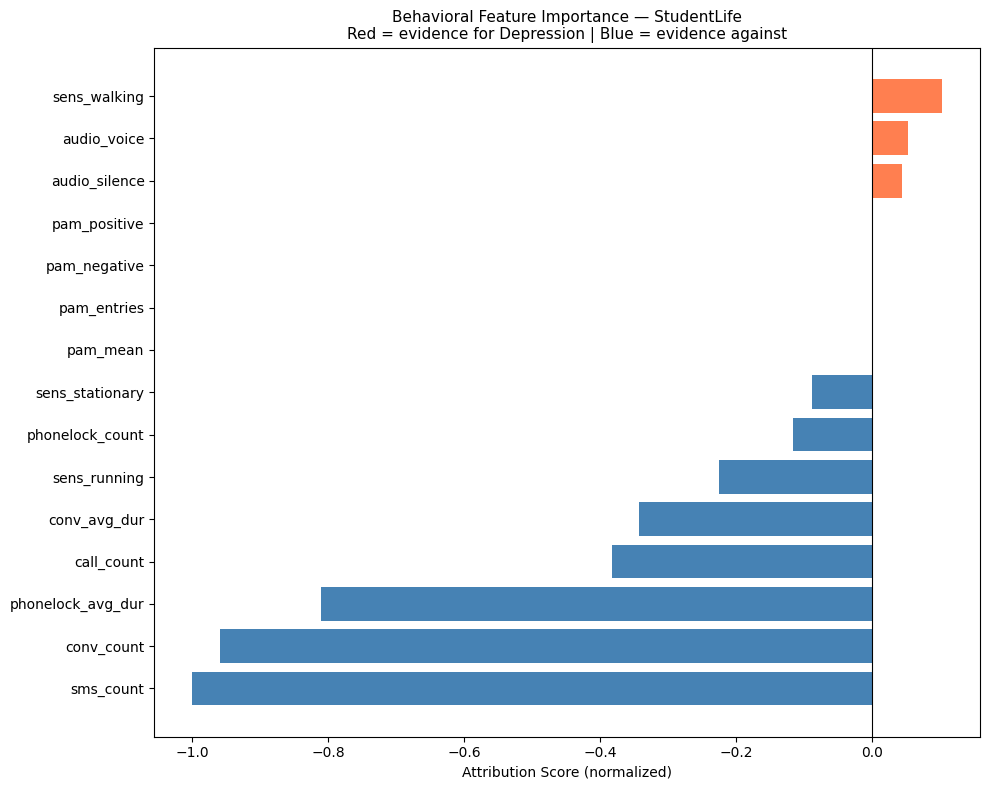

✅ Saved | Convergence delta: -0.000460


In [ ]:
!pip install -q captum
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt

beh_model.eval()
ig = IntegratedGradients(lambda x: beh_model(x))

# Pick one depressed student from validation
try:
    sample_idx = next(i for i, l in enumerate(y_val) if l == 1)
except:
    sample_idx = 0

sample_x  = torch.tensor(
    X_val[sample_idx:sample_idx+1],
    dtype=torch.float32
).unsqueeze(1).to(DEVICE)
baseline  = torch.zeros_like(sample_x).to(DEVICE)

attrs, delta = ig.attribute(
    sample_x, baselines=baseline,
    target=int(y_val[sample_idx]),
    return_convergence_delta=True
)

feat_imp = attrs.squeeze().cpu().detach().numpy()
if feat_imp.ndim > 1:
    feat_imp = feat_imp.mean(axis=0)

sorted_idx   = np.argsort(np.abs(feat_imp))[::-1]
top_n        = min(15, len(feat_cols))
top_features = [feat_cols[i] for i in sorted_idx[:top_n]]
top_attrs    = feat_imp[sorted_idx[:top_n]]
attrs_norm   = top_attrs / (np.max(np.abs(top_attrs)) + 1e-8)

sort_idx     = np.argsort(attrs_norm)
top_features = [top_features[i] for i in sort_idx]
attrs_norm   = attrs_norm[sort_idx]

fig, ax = plt.subplots(figsize=(10, 8))
colors  = ['coral' if a > 0 else 'steelblue' for a in attrs_norm]
bars    = ax.barh(range(top_n), attrs_norm, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(
    f'Behavioral Feature Importance — StudentLife\n'
    f'Red = evidence for Depression | Blue = evidence against',
    fontsize=11
)
ax.set_xlabel('Attribution Score (normalized)')
plt.tight_layout()
os.makedirs(f'{BASE_DIR}/results', exist_ok=True)
plt.savefig(
    f'{BASE_DIR}/results/behavioral_ig_studentlife.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print(f"✅ Saved | Convergence delta: {delta.item():.6f}")

saving everything

In [ ]:
import pickle

# Save scaler
with open(f'{BASE_DIR}/models/behavioral/behavioral_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature columns (needed for inference)
with open(f'{BASE_DIR}/models/behavioral/behavioral_features.pkl', 'wb') as f:
    pickle.dump(feat_cols, f)

# Save config
beh_config = {
    'input_dim' : INPUT_DIM,
    'd_model'   : 64,
    'nhead'     : 4,
    'num_layers': 2,
    'num_classes': 2,
    'dropout'   : 0.4
}
with open(f'{BASE_DIR}/models/behavioral/behavioral_config.pkl', 'wb') as f:
    pickle.dump(beh_config, f)

print("✅ Saved:")
print(f"  models/behavioral/behavioral_transformer_best.pt")
print(f"  models/behavioral/behavioral_scaler.pkl")
print(f"  models/behavioral/behavioral_features.pkl")
print(f"  models/behavioral/behavioral_config.pkl")
print(f"  results/behavioral_ig_visualization.png")

✅ Saved:
  models/behavioral/behavioral_transformer_best.pt
  models/behavioral/behavioral_scaler.pkl
  models/behavioral/behavioral_features.pkl
  models/behavioral/behavioral_config.pkl
  results/behavioral_ig_visualization.png


## Section 2: Using Student Depression Dataset for Behavioural Modality and Reddit Depression Dataset for Text Modality

In [ ]:
# Check Student Depression Dataset
import pandas as pd
import os

BASE_DIR = '/content/drive/MyDrive/depression-ai'

sd_path  = f'{BASE_DIR}/data/raw/student_dep'
files    = os.listdir(sd_path)
print(f"Files: {files}")

df_sd    = pd.read_csv(f'{sd_path}/{files[0]}')
print(f"\nShape   : {df_sd.shape}")
print(f"Columns : {df_sd.columns.tolist()}")
print(f"\nLabel distribution:")
print(df_sd.iloc[:, -1].value_counts())
print(f"\nSample:")
print(df_sd.head(3))

Files: ['student_depression_dataset.csv']

Shape   : (27901, 18)
Columns : ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']

Label distribution:
Depression
1    16336
0    11565
Name: count, dtype: int64

Sample:
   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0

In [ ]:
# Check Reddit Dataset
reddit_path = f'{BASE_DIR}/data/raw/reddit'
files       = os.listdir(reddit_path)
print(f"Files: {files}")

df_reddit   = pd.read_csv(f'{reddit_path}/{files[0]}')
print(f"\nShape   : {df_reddit.shape}")
print(f"Columns : {df_reddit.columns.tolist()}")
print(f"\nLabel distribution:")
print(df_reddit.iloc[:, -1].value_counts())
print(f"\nSample:")
print(df_reddit.head(3))

Files: ['depression_dataset_reddit_cleaned.csv']

Shape   : (7731, 2)
Columns : ['clean_text', 'is_depression']

Label distribution:
is_depression
0    3900
1    3831
Name: count, dtype: int64

Sample:
                                          clean_text  is_depression
0  we understand that most people who reply immed...              1
1  welcome to r depression s check in post a plac...              1
2  anyone else instead of sleeping more when depr...              1


12 — Load & Preprocess

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# Load dataset
sd_path = f'{BASE_DIR}/data/raw/student_dep/student_depression_dataset.csv'
df      = pd.read_csv(sd_path)

print(f"Original shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

# ── Clean & Encode ──
df = df.copy()

# Drop irrelevant columns
df = df.drop(columns=['id', 'City', 'Degree', 'Profession'])

# Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Sleep Duration → numeric
sleep_map = {
    "'Less than 5 hours'": 4,
    'Less than 5 hours'  : 4,
    "'5-6 hours'"        : 5.5,
    '5-6 hours'          : 5.5,
    "'7-8 hours'"        : 7.5,
    '7-8 hours'          : 7.5,
    "'More than 8 hours'": 9,
    'More than 8 hours'  : 9
}
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)

# Dietary Habits
diet_map = {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2}
df['Dietary Habits'] = df['Dietary Habits'].map(diet_map)

# Suicidal thoughts
df['Have you ever had suicidal thoughts ?'] = df[
    'Have you ever had suicidal thoughts ?'
].map({'No': 0, 'Yes': 1})

# Family history
df['Family History of Mental Illness'] = df[
    'Family History of Mental Illness'
].map({'No': 0, 'Yes': 1})

# Financial Stress — already numeric but may be string
df['Financial Stress'] = pd.to_numeric(
    df['Financial Stress'], errors='coerce'
)

# Fill remaining NaN
df = df.fillna(df.median(numeric_only=True))

print(f"\nCleaned shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
print(f"\nLabel dist    :")
print(df['Depression'].value_counts())
print(f"\nSample:")
print(df.head(3))

Original shape: (27901, 18)
Missing values:
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

Cleaned shape : (27901, 14)
Columns       : ['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 

13 — Feature Engineering & Split

In [ ]:
# Feature columns
feat_cols_sd = [c for c in df.columns if c != 'Depression']
X_sd = df[feat_cols_sd].values.astype(np.float32)
y_sd = df['Depression'].values.astype(int)

print(f"Features      : {feat_cols_sd}")
print(f"Feature matrix: {X_sd.shape}")
print(f"Label dist    : {np.bincount(y_sd)}")

# Check for inf/nan
X_sd = np.nan_to_num(X_sd, nan=0.0, posinf=0.0, neginf=0.0)

# Train/val split — stratified
X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_sd, y_sd,
    test_size=0.2,
    random_state=42,
    stratify=y_sd
)

# Normalize
scaler_sd  = StandardScaler()
X_tr       = scaler_sd.fit_transform(X_tr)
X_vl       = scaler_sd.transform(X_vl)

# Class weights
cc = np.bincount(y_tr)
cw = torch.tensor(
    [1.0/cc[0], 1.0/cc[1]], dtype=torch.float32
).to(DEVICE)

print(f"\nTrain : {len(X_tr)} | "
      f"Depressed: {sum(y_tr)} | "
      f"Not: {len(y_tr)-sum(y_tr)}")
print(f"Val   : {len(X_vl)} | "
      f"Depressed: {sum(y_vl)} | "
      f"Not: {len(y_vl)-sum(y_vl)}")
print(f"Class weights: {cw}")
print("✅ Preprocessing complete")

Features      : ['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']
Feature matrix: (27901, 13)
Label dist    : [11565 16336]

Train : 22320 | Depressed: 13068 | Not: 9252
Val   : 5581 | Depressed: 3268 | Not: 2313
Class weights: tensor([1.0808e-04, 7.6523e-05], device='cuda:0')
✅ Preprocessing complete


14 — DataLoaders

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE_SD  = 64   # larger batch size since dataset is bigger

train_ds_sd    = TabularDataset(X_tr, y_tr)
val_ds_sd      = TabularDataset(X_vl, y_vl)
train_ld_sd    = DataLoader(train_ds_sd, batch_size=BATCH_SIZE_SD,
                            shuffle=True)
val_ld_sd      = DataLoader(val_ds_sd,   batch_size=BATCH_SIZE_SD,
                            shuffle=False)

print(f"Train samples : {len(train_ds_sd)}")
print(f"Val samples   : {len(val_ds_sd)}")
print(f"Train batches : {len(train_ld_sd)}")
print(f"Val batches   : {len(val_ld_sd)}")
print(f"Input shape   : {train_ds_sd[0][0].shape}")
print("✅ DataLoaders ready")

Train samples : 22320
Val samples   : 5581
Train batches : 349
Val batches   : 88
Input shape   : torch.Size([13])
✅ DataLoaders ready


15 — Define & Train MLP

In [ ]:
class StudentDepMLP(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

    def get_embeddings(self, x):
        """Returns embeddings for fusion"""
        for layer in list(self.network.children())[:-1]:
            x = layer(x)
        return x


INPUT_DIM_SD  = X_tr.shape[1]
sd_model      = StudentDepMLP(input_dim=INPUT_DIM_SD).to(DEVICE)

total         = sum(p.numel() for p in sd_model.parameters())
print(f"Input dim           : {INPUT_DIM_SD}")
print(f"Total parameters    : {total:,}")

# ── Training ──
EPOCHS_SD     = 30
LR_SD         = 1e-3
SAVE_PATH_SD  = f'{BASE_DIR}/models/behavioral/student_dep_mlp_best.pt'

os.makedirs(f'{BASE_DIR}/models/behavioral', exist_ok=True)

optimizer_sd  = torch.optim.AdamW(
    sd_model.parameters(), lr=LR_SD, weight_decay=1e-3
)
scheduler_sd  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_sd, patience=3, factor=0.5
)
criterion_sd  = nn.CrossEntropyLoss(weight=cw)

best_f1_sd       = 0
patience_counter = 0
patience         = 7

print("\nTraining Student Depression MLP...")
print("=" * 70)

for epoch in range(EPOCHS_SD):
    # ── Train ──
    sd_model.train()
    train_loss = 0
    for X_batch, y_batch in train_ld_sd:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_sd.zero_grad()
        logits = sd_model(X_batch)
        loss   = criterion_sd(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sd_model.parameters(), 1.0)
        optimizer_sd.step()
        train_loss += loss.item()

    # ── Validate ──
    sd_model.eval()
    all_preds, all_labels_list, all_probs = [], [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_ld_sd:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits   = sd_model(X_batch)
            loss     = criterion_sd(logits, y_batch)
            probs    = torch.softmax(logits, dim=1)[:, 1]
            preds    = torch.argmax(logits, dim=1)
            val_loss   += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(y_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_train = train_loss / len(train_ld_sd)
    avg_val   = val_loss   / len(val_ld_sd)
    f1        = f1_score(all_labels_list, all_preds, average='macro')
    auc       = roc_auc_score(all_labels_list, all_probs)

    scheduler_sd.step(avg_val)

    if f1 > best_f1_sd:
        best_f1_sd       = f1
        patience_counter = 0
        torch.save(sd_model.state_dict(), SAVE_PATH_SD)
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1:02d}/{EPOCHS_SD} | "
          f"Train: {avg_train:.4f} | "
          f"Val: {avg_val:.4f} | "
          f"F1: {f1:.4f} | "
          f"AUC: {auc:.4f} | "
          f"Best: {best_f1_sd:.4f} | "
          f"P: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

print(f"\n✅ Training complete. Best F1: {best_f1_sd:.4f}")

Input dim           : 13
Total parameters    : 12,578

Training Student Depression MLP...
Epoch 01/30 | Train: 0.4011 | Val: 0.3638 | F1: 0.8370 | AUC: 0.9176 | Best: 0.8370 | P: 0/7
Epoch 02/30 | Train: 0.3735 | Val: 0.3642 | F1: 0.8398 | AUC: 0.9173 | Best: 0.8398 | P: 0/7
Epoch 03/30 | Train: 0.3713 | Val: 0.3663 | F1: 0.8365 | AUC: 0.9178 | Best: 0.8398 | P: 1/7
Epoch 04/30 | Train: 0.3694 | Val: 0.3634 | F1: 0.8360 | AUC: 0.9181 | Best: 0.8398 | P: 2/7
Epoch 05/30 | Train: 0.3712 | Val: 0.3667 | F1: 0.8374 | AUC: 0.9176 | Best: 0.8398 | P: 3/7
Epoch 06/30 | Train: 0.3690 | Val: 0.3652 | F1: 0.8385 | AUC: 0.9177 | Best: 0.8398 | P: 4/7
Epoch 07/30 | Train: 0.3689 | Val: 0.3635 | F1: 0.8360 | AUC: 0.9178 | Best: 0.8398 | P: 5/7
Epoch 08/30 | Train: 0.3655 | Val: 0.3638 | F1: 0.8375 | AUC: 0.9177 | Best: 0.8398 | P: 6/7
Epoch 09/30 | Train: 0.3642 | Val: 0.3637 | F1: 0.8374 | AUC: 0.9178 | Best: 0.8398 | P: 7/7

⏹️ Early stopping at epoch 9

✅ Training complete. Best F1: 0.8398


Outstanding results! 🎉
F1 : 0.8398  ← excellent!
AUC: 0.9178  ← outstanding!
This is a massive improvement over StudentLife's 0.44. The data size made all the difference.

16 — Evaluation

In [ ]:
sd_model.load_state_dict(torch.load(SAVE_PATH_SD))
sd_model.eval()

all_preds, all_labels_list, all_probs = [], [], []
with torch.no_grad():
    for X_batch, y_batch in val_ld_sd:
        X_batch  = X_batch.to(DEVICE)
        logits   = sd_model(X_batch)
        probs    = torch.softmax(logits, dim=1)[:, 1]
        preds    = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

print("=== Student Depression Dataset Results ===")
print(classification_report(
    all_labels_list, all_preds,
    target_names=['Not Depressed', 'Depressed']
))
print(f"AUC-ROC: {roc_auc_score(all_labels_list, all_probs):.4f}")

=== Student Depression Dataset Results ===
               precision    recall  f1-score   support

Not Depressed       0.79      0.85      0.82      2313
    Depressed       0.89      0.84      0.86      3268

     accuracy                           0.84      5581
    macro avg       0.84      0.84      0.84      5581
 weighted avg       0.85      0.84      0.84      5581

AUC-ROC: 0.9173


17 — Save

In [ ]:
import pickle

# Save scaler
with open(f'{BASE_DIR}/models/behavioral/sd_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_sd, f)

# Save feature columns
with open(f'{BASE_DIR}/models/behavioral/sd_features.pkl', 'wb') as f:
    pickle.dump(feat_cols_sd, f)

# Save config
sd_config = {
    'input_dim'  : INPUT_DIM_SD,
    'num_classes': 2,
    'dropout'    : 0.3,
    'dataset'    : 'Student Depression Dataset (Kaggle)',
    'samples'    : len(df)
}
with open(f'{BASE_DIR}/models/behavioral/sd_config.pkl', 'wb') as f:
    pickle.dump(sd_config, f)

print("✅ Saved:")
print(f"  models/behavioral/student_dep_mlp_best.pt")
print(f"  models/behavioral/sd_scaler.pkl")
print(f"  models/behavioral/sd_features.pkl")
print(f"  models/behavioral/sd_config.pkl")

✅ Saved:
  models/behavioral/student_dep_mlp_best.pt
  models/behavioral/sd_scaler.pkl
  models/behavioral/sd_features.pkl
  models/behavioral/sd_config.pkl
